# 01. Threshold Optimization for Extreme Value Theory (EVT)

## Objective
In quantitative risk management, selecting the appropriate Peak-Over-Threshold (POT) for heavy-tailed data is a classic bias-variance tradeoff. 
* **Too low:** Non-extreme data is included, leading to a biased fit.
* **Too high:** Extreme scarcity of data points inflates the variance of parameter estimation.

This notebook implements a rigorous grid search to find the optimal absolute threshold ($u$) by minimizing the **Conditional Tail Anderson-Darling (A-D) Statistic**, ensuring the tail topology is accurately captured before quantum state encoding.

In [4]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.distribution_fit import optimize_gpd_threshold_ad, fit_spliced_distribution

plt.style.use('seaborn-v0_8-whitegrid')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Data Loading and Preprocessing
We load the empirical disaster loss dataset (e.g., FEMA claims). Minor claims (e.g., < $1,000) are filtered out to focus the computational resources on the tail risk profile.

In [9]:
# Define the path to your dataset (adjust if necessary)
data_path = '../data/fema_sample_data.csv' 

# Load the dataset
df = pd.read_csv(data_path)

# Extract numerical amounts, drop NaNs, and filter low-severity noise
raw_data = pd.to_numeric(df['projectAmount'], errors='coerce').dropna().values
data = raw_data[raw_data > 1000]

print(f"Dataset successfully loaded from: {data_path}")
print(f"Total valid extreme samples: {len(data):,}")
print(f"Empirical Skewness: {pd.Series(data).skew():.2f} (Indicating heavy right-tail)")

Dataset successfully loaded from: ../fema_2019_2023_natural_data.csv
Total valid extreme samples: 110,632
Empirical Skewness: 220.44 (Indicating heavy right-tail)


## 2. A-D Statistic Optimization
We evaluate candidate thresholds spanning from the 90th to the 98th percentiles. For each candidate, a Generalized Pareto Distribution (GPD) is fitted to the excesses, and the conditional A-D distance is computed.

In [10]:
# Execute grid search optimization
best_u, best_q, quantiles, ad_scores = optimize_gpd_threshold_ad(
    data, 
    q_start=0.90, 
    q_end=0.98, 
    step=0.005
)

print("=" * 50)
print(f"Optimization Complete")
print("-" * 50)
print(f"Optimal Quantile Picked: {best_q * 100:.2f}%")
print(f"Optimal Absolute Threshold (u): ${best_u:,.2f}")
print("=" * 50)

Optimization Complete
--------------------------------------------------
Optimal Quantile Picked: 94.50%
Optimal Absolute Threshold (u): $1,919,204.96


## 3. Visualization of the Optimization Curve
The objective function typically exhibits a "U-shape". The global minimum represents the optimal balance point where the GPD assumptions perfectly align with the empirical tail behavior.

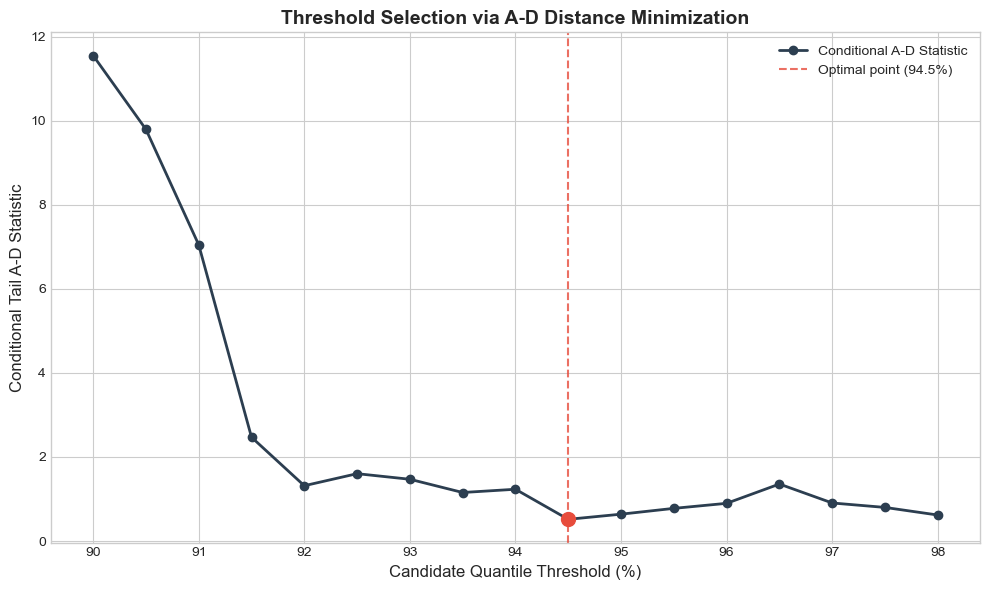

In [11]:
plt.figure(figsize=(10, 6))

# Plot the A-D scores
plt.plot(quantiles * 100, ad_scores, marker='o', color='#2c3e50', linewidth=2, label='Conditional A-D Statistic')

# Highlight the optimal threshold
plt.axvline(x=best_q * 100, color='#e74c3c', linestyle='--', alpha=0.8, label=f'Optimal point ({best_q*100:.1f}%)')
plt.scatter([best_q * 100], [min(ad_scores)], color='#e74c3c', s=100, zorder=5)

plt.title('Threshold Selection via A-D Distance Minimization', fontsize=14, fontweight='bold')
plt.xlabel('Candidate Quantile Threshold (%)', fontsize=12)
plt.ylabel('Conditional Tail A-D Statistic', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## 4. Fitting the Spliced Distribution
Using the dynamically computed optimal threshold ($u$), we construct the hybrid probability model:
* **Body ($x \le u$):** Lognormal Distribution
* **Tail ($x > u$):** Generalized Pareto Distribution (GPD)

In [12]:
# Fit the robust spliced model using the optimized threshold
w, threshold, ln_params, gpd_params = fit_spliced_distribution(data, threshold=best_u)

print("=== Spliced Model Successfully Calibrated ===")
print(f"Attachment Point (u): ${threshold:,.2f}")
print(f"Probability Mass below threshold (w): {w:.4f}")
print(f"Lognormal Params -> Shape: {ln_params[0]:.4f}, Scale: {ln_params[1]:.4f}")
print(f"GPD Params       -> Shape (xi): {gpd_params[0]:.4f}, Scale (beta): {gpd_params[1]:.4f}")

=== Spliced Model Successfully Calibrated ===
Attachment Point (u): $1,919,204.96
Probability Mass below threshold (w): 0.9450
Lognormal Params -> Shape: 1.5766, Scale: 47295.5739
GPD Params       -> Shape (xi): 0.9627, Scale (beta): 2926976.5058
